# Projet de sélection — Exploration de données avec python

##  1. Importation des bibliothèques

In [15]:
import pandas as pd
import matplotlib.pyplot  as plt

## 2. Chargement du fichier CSV

In [16]:
data = pd.read_csv("dataset-sell4all.csv")

## 3. Affichage des cinq premières lignes

In [17]:
data.head()

,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,5-Apr-21,4:39,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,"oct. 10, 2021",0:36,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2-Jul-22,3:37,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,19-Feb-22,2:34,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,31-Mar-22,6:28,42,Women,13


## 4. Résumé technique des données

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Name                     505 non-null    object
 1   Phone Number             505 non-null    object
 2   Email                    505 non-null    object
 3   Address                  505 non-null    object
 4   Country                  505 non-null    object
 5   Postal code              505 non-null    object
 6   Last date of connection  505 non-null    object
 7   Last time of connection  505 non-null    object
 8   Age                      505 non-null    int64 
 9   Gender                   505 non-null    object
 10  Customer spendings       505 non-null    int64 
dtypes: int64(2), object(9)
memory usage: 43.5+ KB


## Explication du résumé technique

Après avoir exécuté `data.info()`, j'ai constaté que le fichier contient **505 lignes** et **11 colonnes**.

Toutes les colonnes possèdent **505 valeurs non nulles**, ce qui montre que les données sont complètes et qu'il n'y a pas de valeurs manquantes.

Les données sont de deux types :
- **object** pour les informations sous forme de texte, comme le nom, le pays ou le genre.
- **int64** pour les valeurs numériques entières, comme l'âge et les dépenses des clients.

Ces informations me permettent de vérifier la structure des données avant de commencer leur analyse et leur nettoyage.

# 4. Analyse statistique

## Calcul de la moyenne

In [19]:
data['Age'].mean()

np.float64(46.08316831683168)

In [20]:
data['Customer spendings'].mean()

np.float64(311.16831683168317)

## Calcul de la médiane

In [21]:
data['Age'].median()

np.float64(46.0)

In [22]:
data['Customer spendings'].median()

np.float64(307.0)

## Médiane de l'âge par pays

In [23]:
data.groupby("Country")["Age"].median()

Country
Australia             44.0
Austria               43.0
Belgium               39.0
Brazil                49.5
Canada                46.0
Chile                 46.0
China                 35.0
Colombia              29.0
Costa Rica            48.0
France                56.5
Germany               53.0
India                 45.5
Indonesia             41.5
Ireland               49.0
Italy                 41.0
Mexico                47.0
Netherlands           48.0
New Zealand           38.0
Nigeria               37.0
Norway                54.0
Pakistan              44.0
Peru                  38.0
Philippines           51.0
Poland                49.5
Russian Federation    48.0
Singapore             41.5
South Africa          43.0
South Korea           49.5
Spain                 54.5
Sweden                40.0
Turkey                60.0
Ukraine               46.0
United Kingdom        48.5
United States         48.5
Vietnam               48.0
Name: Age, dtype: float64

# 5. Visualisation des données

## Dépenses des clients par pays

In [24]:
cs = data.groupby("Country")["Customer spendings"].sum()

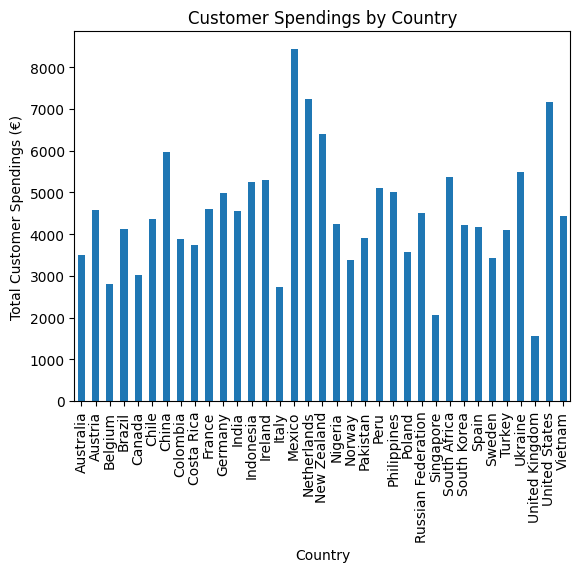

In [26]:
cs.plot(
    kind="bar",
    title="Customer Spendings by Country"
)

plt.xlabel("Country")
plt.ylabel("Total Customer Spendings (€)")
plt.show()

Ce graphique présente le total des dépenses des clients pour chaque pays.

- L'axe horizontal (X) représente les pays.
- L'axe vertical (Y) représente le total des dépenses des clients.

Ce graphique permet de comparer facilement les dépenses entre les différents pays.

# 6. Nettoyage des données

## Suppression des clients ayant dépensé moins de 10 €

In [30]:
data = data[data["Customer spendings"] >= 10]

## Suppression des doublons

In [31]:
data = data.drop_duplicates()

# 7. Préparation des données finales

## Sélection des colonnes

In [32]:
data = data[["Country", "Age", "Gender", "Customer spendings"]]

## Export des données nettoyées

In [33]:
data.to_csv("dataset-sell4all-clean.csv", index=False)